# Example 5 - using realistic simulation to get more accurate limits!
(Thanks Mathis for the sim files!)

This example will show all the steps from examples 1-4.
We will:

1. Load the new data-set (more complete)
2. Implement official data-cuts (as is now used for Mathis's bb analysis)
3. Calculate 1D frequentist limit with these cuts
4. Loosen up the cuts a bit and create DataProcessND for ND optimization
5. Run a short optimization with hopes of improving the limits at least slightly :)
6. Run bayesian limit on optimized cuts.

All will be done on "per phase basis" so we can split into 4 groups - each doing the same in parallel.

In [1]:
#### 
#### WORK IN PROGRESS
####
import Pkg;
Pkg.activate("/sps/nemo/scratch/mpetro/Sensitivity_training/")
using SNSensitivityEstimate, UnROOT, FHist, CairoMakie, CSV, DataFramesMeta
using Random, LinearAlgebra, Statistics, Distributions, BAT, BinnedModels, StatsBase, DensityInterface, IntervalSets, SpecialFunctions, ValueShapes
using Distributions, ColorSchemes

  Activating project at `/sps/nemo/scratch/mpetro/Sensitivity_training`


# Load data 
Here we use `../data/mathis_data_info_final.csv` a file containing info on the Mathis's data-files.

Here we must define phase - 0,1,2,3!

In [23]:
# STEP 1: Load the data

# Start is the same as in ex1_background.jl, we load data and create DataProcess objects. 
data_info = CSV.read("../data/mathis_data_info_final.csv", DataFrame)

# Select which phase we process
phase = "phase_3"

selected_files = @chain data_info begin
    @subset :phase .== phase
    @subset .!occursin.("reduces", :file_path) 
end

Row,phase,name,is_signal,file_path,activity_bq,amount,time_s,phase_time_s,nb_events
,String7,String15,Bool,String,Float64,Float64,Float64,Float64,Int64
1,phase_3,bb,false,data/mathis_files/bb/phase_3/bb_phase_3.root,0.0113606,1.0,9.0193e7,6.61564e6,30000000
2,phase_3,bb0nu,true,data/mathis_files/bb0nu/phase_3/simu_0/rec_bb0nu_3_0.root,1.0,1.0,9.0193e7,3.27552e6,1000000
3,phase_3,bi_5_pmt,false,data/mathis_files/bi_5_pmt/phase_3/bi_5_pmt_phase_3.root,24.7122,1.0,9.0193e7,6.61564e6,5000000000
4,phase_3,bi_foil,false,data/mathis_files/bi_foil/phase_3/bi_foil_phase_3.root,6.25e-5,1.0,9.0193e7,6.61564e6,10000000
5,phase_3,bi_g_pmt,false,data/mathis_files/bi_g_pmt/phase_3/bi_g_pmt_phase_3.root,8.59555,1.0,9.0193e7,6.61564e6,9900000000
6,phase_3,bi_pmt,false,data/mathis_files/bi_pmt/phase_3/bi_pmt_phase_3.root,141.0,1.0,9.0193e7,6.61564e6,5000000000
7,phase_3,bi_x_pmt,false,data/mathis_files/bi_x_pmt/phase_3/bi_x_pmt_phase_3.root,22.6922,1.0,9.0193e7,6.61564e6,5000000000
8,phase_3,k,false,data/mathis_files/k/phase_3/k_phase_3.root,0.366875,1.0,9.0193e7,6.61564e6,500000000
9,phase_3,k_5_pmt,false,data/mathis_files/k_5_pmt/phase_3/k_5_pmt_phase_3.root,54.2786,1.0,9.0193e7,6.61564e6,10000000000


# Load data and apply data-selection cuts

In [24]:
data_files = [UnROOT.ROOTFile(joinpath("..",file_path)) for file_path in selected_files.file_path] 
tree_name = "Event" 

# we don't need all the variables, we can select a few to use for the analysis.
var_names = [ 
    "energy_elec_sum", 
    "angle_3D_between_ep_em", 
    "delta_y_elec",
    "delta_z_elec",
    "diff_time_elec",
    "energy_elec_1",
    "energy_elec_2",
    "hit_the_same_calo_hit",
    "closest_gamma",
    "closest_elec",
    "closest_track",
    "closest_time_track",
    "has_kinks",
    "num_om_elec_f",
    "vertex_3D_start_y",
    "vertex_3D_start_z"
    ]

data_tables = [UnROOT.LazyTree(data_file, tree_name, var_names) for data_file in data_files] 


# define the boundaries of the data-cuts
var_bounds = (
    energy_elec_sum = (0.7, 4),
    angle_3D_between_ep_em = (0, 180),
    delta_y_elec = (0, 100),
    delta_z_elec = (0, 100),
    diff_time_elec = (-1.5, 1.5),
    energy_elec_1 = (0.35, 4),
    energy_elec_2 = (0.35, 4),
)

# Apply bounds only for keys present in `var_bounds`.
filtered_data_tables = [SNSensitivityEstimate.filter_data(table, var_names, var_bounds) for table in data_tables]


[ Info: Key hit_the_same_calo_hit not found in roi, skipping filtering for this variable.
[ Info: Key closest_gamma not found in roi, skipping filtering for this variable.
[ Info: Key closest_elec not found in roi, skipping filtering for this variable.
[ Info: Key closest_track not found in roi, skipping filtering for this variable.
[ Info: Key closest_time_track not found in roi, skipping filtering for this variable.
[ Info: Key has_kinks not found in roi, skipping filtering for this variable.
[ Info: Key num_om_elec_f not found in roi, skipping filtering for this variable.
[ Info: Key vertex_3D_start_y not found in roi, skipping filtering for this variable.
[ Info: Key vertex_3D_start_z not found in roi, skipping filtering for this variable.
[ Info: Key hit_the_same_calo_hit not found in roi, skipping filtering for this variable.
[ Info: Key closest_gamma not found in roi, skipping filtering for this variable.
[ Info: Key closest_elec not found in roi, skipping filtering for this var

20-element Vector{LazyTree with 16 branches:
closest_time_track, energy_elec_2, energy_elec_1, closest_track, hit_the_same_calo_hit...
}:
 ┌─────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────
│ Row │ closest_time_tr │ energy_elec_2 │ energy_elec_1 │ closest_track │ hit_ ⋯
│     │ Float64         │ Float64       │ Float64       │ Float64       │ Bool ⋯
├─────┼─────────────────┼───────────────┼───────────────┼───────────────┼───────
│ 1   │ 1.0e6           │ 0.77678925    │ 0.38795266    │ 1.0e9         │ fals ⋯
│ 2   │ 1.0e6           │ 1.29011774    │ 0.44278315    │ 1.0e9         │ fals ⋯
│ 3   │ 1.0e6           │ 0.43874533    │ 0.80288282    │ 1.0e9         │ fals ⋯
│ 4   │ 1.0e6           │ 0.70188852    │ 0.43227537    │ 1.0e9         │ fals ⋯
│ 5   │ 1.0e6           │ 0.36737474    │ 0.92317076    │ 1.0e9         │ fals ⋯
│ 6   │ 1.0e6           │ 0.69790123    │ 0.61057098    │ 1.0e9         │ fals ⋯
│ 7   │ 1.0e6           │ 0.54587720    │ 0.6854146

Additionally we implement selection which is not out-the-box available -> redid Mathis's cuts. 

In [25]:
# Apply additional topological cuts and store filtered tables back.
for i in eachindex(filtered_data_tables)
    table = filtered_data_tables[i]
    cut_vertex_dist = sqrt.(table.delta_y_elec .* table.delta_y_elec .+ table.delta_z_elec .* table.delta_z_elec) .>= 100
    cut_same_calo   = table.hit_the_same_calo_hit .== 1
    cut_gam         = abs.(table.closest_gamma) .<= 50
    cut_elec        = abs.(table.closest_elec) .<= 25
    cut_track       = abs.(table.closest_track) .< 200
    cut_ttrack      = abs.(table.closest_time_track) .< 10
    cut_kinks       = table.has_kinks .== 1

    n_evt = length(table)
    cut_om_size = [length(table.num_om_elec_f[j]) != 2 for j in 1:n_evt]

    cut_om_range = falses(n_evt)
    for j in 1:n_evt
        if !cut_om_size[j]
            om0 = table.num_om_elec_f[j][1]
            om1 = table.num_om_elec_f[j][2]
            cut_om_range[j] = (om0 > 520 || om1 > 520)
        end
    end

    cut_vertex_region = falses(n_evt)
    for j in 1:n_evt
        if !cut_om_size[j] && !cut_om_range[j] && length(table.vertex_3D_start_y[j]) >= 2 && length(table.vertex_3D_start_z[j]) >= 2
            y_mid = 0.5 * (table.vertex_3D_start_y[j][1] + table.vertex_3D_start_y[j][2])
            z_mid = 0.5 * (table.vertex_3D_start_z[j][1] + table.vertex_3D_start_z[j][2])

            cut_vertex_region[j] = (
                ((y_mid - 1180) / 60)^2 + ((z_mid + 850) / 140)^2 <= 1 ||
                ((y_mid - 1144) / 25)^2 + ((z_mid - 196) / 40)^2 <= 1 ||
                ((y_mid - 1114) / 25)^2 + ((z_mid + 257) / 40)^2 <= 1 ||
                abs(y_mid) > 2360 || abs(z_mid) > 1340
            )
        end
    end

    # `cut_om_good` intentionally omitted here: OM quality map/helper is defined externally.
    keep = .!(cut_vertex_dist .| cut_same_calo .| cut_gam .| cut_elec .| cut_track .| cut_ttrack .| cut_kinks .| cut_om_size .| cut_om_range .| cut_vertex_region)
    filtered_data_tables[i] = table[keep]
end

In [26]:
processes = [
    SNSensitivityEstimate.DataProcess(
        collect(filtered_data_tables[i].energy_elec_sum), # Here we specify a single variable to be used. In later stages we will use N-dimensional data vectors.
        String(selected_files.name[i]), 
        selected_files.is_signal[i], 
        selected_files.activity_bq[i], 
        selected_files.time_s[i], 
        selected_files.nb_events[i], 
        0:0.1:4, 
        selected_files.amount[i], 
    ) for i in 1:length(filtered_data_tables)
]

20-element Vector{DataProcess}:
 DataProcess([1.1647419213660413, 1.7329008938423887, 1.241628154686004, 1.1341638930810913, 1.2905455066611946, 1.3084722231371666, 1.2312918477964745, 2.3464633177553345, 1.8600903680112073, 1.0243238714479461  …  1.4760957076178511, 1.5061595572441773, 1.372185896984305, 1.454242653978912, 1.4673957621856695, 1.9054229680871693, 1.0922631752063265, 1.0923766413015121, 2.078392409228573, 1.7401310908518013], "bb", false, 0.011360597985528976, 9.019296e7, 30000000, 0.0:0.1:4.0, 1.0, edges: ([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9  …  3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0], [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9  …  3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0])
bin counts: [0.0 0.0 … 0.0452379 0.0452379; 0.0 0.0 … 0.0452379 0.0452379; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0]
total count: 16.800893133333332)
 DataProcess([2.840196059309733, 2.822535509253474, 2.6453400891602517, 2.7986099572783116, 2.790352391222276, 

In [27]:

mutable struct HistogramData
    hist::FHist.Hist1D
    name::String
    is_signal::Bool
end

function HistogramData(process::SNSensitivityEstimate.DataProcess)
    hist = get_bkg_counts_1D(process)
    HistogramData(hist, process.isotopeName, process.signal)
end

all_bkg_histograms = [HistogramData(process) for process in processes if !process.signal]

function merge_hist_by_keyword(histograms::Vector{HistogramData}, keyword::String, merge_name::String)
    merged_hist = FHist.Hist1D(;binedges = histograms[1].hist.binedges)
    is_signal = findfirst(hist -> occursin(keyword, hist.name) && hist.is_signal, histograms) !== nothing
    for hist in histograms
        if occursin(keyword, hist.name)
            # if signal changes within keyword error out
            if hist.is_signal != is_signal
                error("Can only merge histograms with the same signal flag for keyword $keyword")
            end
            merge!(merged_hist, hist.hist)
        end

    end
    return HistogramData(merged_hist, merge_name, is_signal)
end

merge_hist_by_keyword (generic function with 1 method)

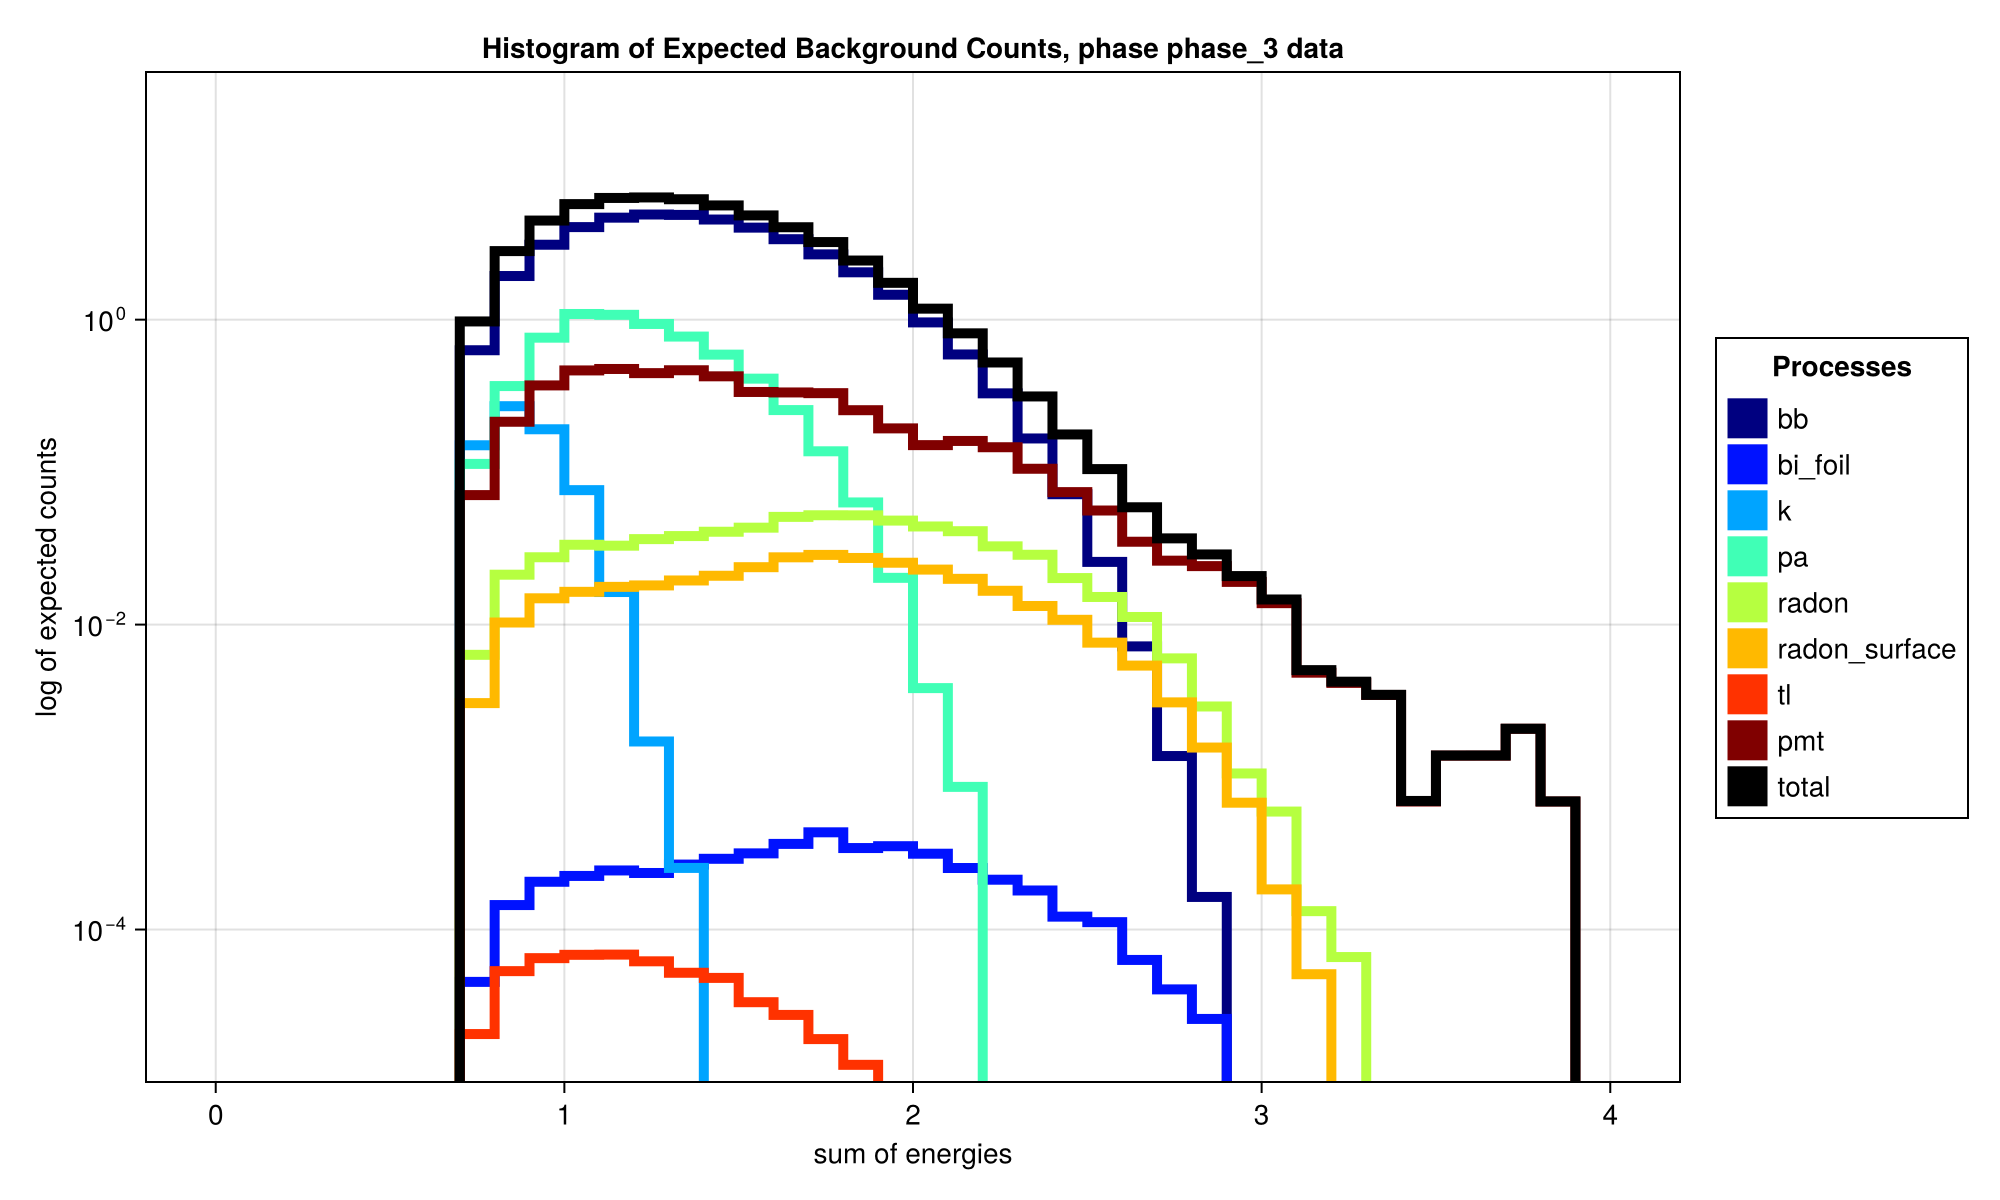

In [28]:

pmt_hists = merge_hist_by_keyword(all_bkg_histograms, "pmt", "pmt")
other_histos = filter(hist -> !occursin("pmt", hist.name), all_bkg_histograms)
all_histos = vcat(other_histos, [pmt_hists])

let
    colors = cgrad(:managua100, length(all_histos); categorical=true)
    histos = [hist.hist for hist in all_histos]

    f = CairoMakie.Figure(size = (1000, 600))
    a = CairoMakie.Axis(
        f[1, 1], 
        title = "Stacked Histogram of Expected Background Counts, phase $phase data\nExposure of 17.5 kg.yr", 
        xlabel = "sum of energies", 
        ylabel = "expected counts", 
        # ylabel = "log of expected counts", 
        # yscale = log10
        )
    p = CairoMakie.hist!(a, sum(histos), color = colors[1])
    for i in length(histos):-1:1
        CairoMakie.hist!(a, sum(histos[1:i]), color = colors[i])
    end

    labels = [String(p.name) for p in all_histos]
    elements = [CairoMakie.PolyElement(polycolor = colors[i]) for i in 1:length(labels)]
    title = "Processes"
    
    ylims!(a, 1e-3, nothing)
    CairoMakie.Legend(f[1,2], elements, labels, title)
    # save("data/out/ex1/stacked_background_histogram.png", f)
    f
end

let
    adjusted_per_day_histos = [hist.hist .* (1/2.86/365) for hist in all_histos]
    colors = cgrad(:jet1, length(adjusted_per_day_histos); categorical=true)
    f = CairoMakie.Figure(size = (1000, 600))
    a = CairoMakie.Axis(
        f[1, 1], 
        title = "Histogram of Expected Background Counts, phase $phase data", 
        xlabel = "sum of energies", 
        # ylabel = "expected counts per day", 
        ylabel = "log of expected counts", 
        yscale = log10
        )
    p = CairoMakie.stephist!(a, adjusted_per_day_histos[1], color = colors[1], linewidth = 5)
    for i in 2:length(adjusted_per_day_histos)
        CairoMakie.stephist!(a, adjusted_per_day_histos[i], color = colors[i], linewidth = 5)
    end
    CairoMakie.stephist!(a, sum(adjusted_per_day_histos), color = :black, linewidth = 5)



    labels = [hist.name for hist in all_histos]
    push!(labels, "total")
    elements = [CairoMakie.PolyElement(polycolor = colors[i]) for i in 1:length(labels)-1]
    push!(elements, CairoMakie.PolyElement(polycolor = :black))
    title = "Processes"
    
    ylims!(a, 1e-5, nothing)
    CairoMakie.Legend(f[1,2], elements, labels, title)
    save("../data/out/ex5/stacked_background_histogram_per_day_phase_$phase.png", f, px_per_unit = 2)
    f
end

In [29]:
for i=1:length(processes)
    println("i: $i, process: ", processes[i].isotopeName, ", n = ", integral(get_bkg_counts_1D(processes[i])), ",  activity = ", processes[i].activity, " Bq", " n_pass = ", length(processes[i].dataVector))
end

println("Total expected counts: ", integral(sum(get_bkg_counts_1D.(processes))))
println("\n\n\n")

for i=1:length(processes)
    n_pass = length(processes[i].dataVector)
    eff = n_pass/processes[i].nTotalSim
    a = processes[i].activity
    t = 24*3600
    n_exp_day = round(eff*a*t, digits = 2)
    println("i: $i, process: ", processes[i].isotopeName, ", n_exp_day = ", n_exp_day, ", n_pass = ", n_pass)
end
println("Total expected counts per day: ", round(integral(sum(get_bkg_counts_1D.(processes)))*(1/2.86/365), digits = 2))


i: 1, process: bb, n = 46352.831459629335,  activity = 0.011360597985528976 Bq n_pass = 1357137
i: 2, process: bb0nu, n = 1.7047190983680002e7,  activity = 1.0 Bq n_pass = 189008
i: 3, process: bi_5_pmt, n = 57.95053423791252,  activity = 24.712202609363008 Bq n_pass = 130
i: 4, process: bi_foil, n = 5.013601164000001,  activity = 6.25e-5 Bq n_pass = 8894
i: 5, process: bi_g_pmt, n = 27.72134606293169,  activity = 8.59554873369148 Bq n_pass = 354
i: 6, process: bi_pmt, n = 1854.1688330879997,  activity = 141.0 Bq n_pass = 729
i: 7, process: bi_x_pmt, n = 83.50458787737834,  activity = 22.69224865694551 Bq n_pass = 204
i: 8, process: k, n = 737.4335374692,  activity = 0.366875 Bq n_pass = 11143
i: 9, process: k_5_pmt, n = 59.72566736085956,  activity = 54.278587874136605 Bq n_pass = 122
i: 10, process: k_g_pmt, n = 38.287276489018524,  activity = 18.879508825786644 Bq n_pass = 447
i: 11, process: k_pmt, n = 490.816559376,  activity = 417.0 Bq n_pass = 261
i: 12, process: k_x_pmt, n = 19

In [30]:
# Sensitivity 1D
# Pick signal
signal = get_process("bb0nu", processes)[1]
background = [p for p in processes if !p.signal]
α = 1.64485362695147

t12MapESum = get_tHalf_map(SNparams, α, signal, background...; approximate ="table")
best_t12ESum = get_max_bin(t12MapESum)
expBkgESum = get_bkg_counts_ROI(best_t12ESum, background...)
effbb = lookup(signal, best_t12ESum)
best_sens = get_tHalf(SNparams, effbb, expBkgESum, α; approximate="table")
ThalfbbESum = round(best_sens, sigdigits=3)


┌ Warning: get_bkg_counts(): passed isotope bb0nu is a signal process!!
└ @ SNSensitivityEstimate ~/.julia/packages/SNSensitivityEstimate/Zn51v/src/AbstractProcess.jl:69


5.55e23

# ND optimization

In [31]:
using Metaheuristics

In [32]:
# Sensitivity ND
# define variables to use
var_names_nd = [ 
    "energy_elec_sum", 
    "angle_3D_between_ep_em", 
    "delta_y_elec",
    "delta_z_elec",
    "diff_time_elec",
    "energy_elec_1",
    "energy_elec_2",
    ]

# Next we define the boundaries of the variables in the search space. These boundaries will be used to define the search space for the optimization algorithm.
var_bounds_nd = (
    energy_elec_sum = (2.40, 3.50),
    angle_3D_between_ep_em = (0, 180),
    delta_y_elec = (0, 200),
    delta_z_elec = (0, 200),
    diff_time_elec = (0, 4),
    energy_elec_1 = (0, 3.50),
    energy_elec_2 = (0, 3.50),
)


# Default search resolution (adjust if needed)
var_steps_nd = (
    energy_elec_sum = 0.1, # 100keV
    angle_3D_between_ep_em = 10.0, # 10 degree
    delta_y_elec = 10.0, # 10mm
    delta_z_elec = 10.0, # 10mm
    diff_time_elec = 0.5, # 0.5ns
    energy_elec_1 = 0.10, # 100keV
    energy_elec_2 = 0.10, # 100keV
)

(energy_elec_sum = 0.05, angle_3D_between_ep_em = 5.0, delta_y_elec = 5.0, delta_z_elec = 5.0, diff_time_elec = 0.01, energy_elec_1 = 0.05, energy_elec_2 = 0.05)

In [33]:
selected_tables_nd = [UnROOT.LazyTree(data_file, tree_name, var_names) for data_file in data_files] 
filtered_data_tables_nd = [SNSensitivityEstimate.filter_data(table, var_names_nd, var_bounds_nd) for table in selected_tables_nd]

20-element Vector{LazyTree with 16 branches:
closest_time_track, energy_elec_2, energy_elec_1, closest_track, hit_the_same_calo_hit...
}:
 ┌─────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────
│ Row │ closest_time_tr │ energy_elec_2 │ energy_elec_1 │ closest_track │ hit_ ⋯
│     │ Float64         │ Float64       │ Float64       │ Float64       │ Bool ⋯
├─────┼─────────────────┼───────────────┼───────────────┼───────────────┼───────
│ 1   │ 1.0e6           │ 0.08404120    │ 0.22010218    │ 1.0e9         │ fals ⋯
│ 2   │ 1.0e6           │ 0.90848795    │ 0.32671593    │ 1.0e9         │ fals ⋯
│ 3   │ 1.0e6           │ 0.10164197    │ 0.32700829    │ 1.0e9         │ fals ⋯
│ 4   │ 1.0e6           │ 0.45049139    │ 0.22940084    │ 1.0e9         │ fals ⋯
│ 5   │ 1.0e6           │ 0.84001978    │ 0.47649885    │ 1.0e9         │ fals ⋯
│ 6   │ 2.70943756      │ 0.55874214    │ 0.28754797    │ 518.943781    │ fals ⋯
│ 7   │ 1.0e6           │ 0.40913074    │ 1.0515718

# Slight change here! Since we are using dy, dz separately (and loosened to 200mm) we slightly loosen the cut requirement on $r \equiv \sqrt{dy^2 + dz^2}$

In [34]:

# Apply additional topological cuts and store filtered tables back.
for i in eachindex(filtered_data_tables_nd)
    table = filtered_data_tables_nd[i]
    cut_vertex_dist = sqrt.(table.delta_y_elec .* table.delta_y_elec .+ table.delta_z_elec .* table.delta_z_elec) .>= 300
    cut_same_calo   = table.hit_the_same_calo_hit .== 1
    cut_gam         = abs.(table.closest_gamma) .<= 50
    cut_elec        = abs.(table.closest_elec) .<= 25
    cut_track       = abs.(table.closest_track) .< 200
    cut_ttrack      = abs.(table.closest_time_track) .< 10
    cut_kinks       = table.has_kinks .== 1

    n_evt = length(table)
    cut_om_size = [length(table.num_om_elec_f[j]) != 2 for j in 1:n_evt]

    cut_om_range = falses(n_evt)
    for j in 1:n_evt
        if !cut_om_size[j]
            om0 = table.num_om_elec_f[j][1]
            om1 = table.num_om_elec_f[j][2]
            cut_om_range[j] = (om0 > 520 || om1 > 520)
        end
    end

    cut_vertex_region = falses(n_evt)
    for j in 1:n_evt
        if !cut_om_size[j] && !cut_om_range[j] && length(table.vertex_3D_start_y[j]) >= 2 && length(table.vertex_3D_start_z[j]) >= 2
            y_mid = 0.5 * (table.vertex_3D_start_y[j][1] + table.vertex_3D_start_y[j][2])
            z_mid = 0.5 * (table.vertex_3D_start_z[j][1] + table.vertex_3D_start_z[j][2])

            cut_vertex_region[j] = (
                ((y_mid - 1180) / 60)^2 + ((z_mid + 850) / 140)^2 <= 1 ||
                ((y_mid - 1144) / 25)^2 + ((z_mid - 196) / 40)^2 <= 1 ||
                ((y_mid - 1114) / 25)^2 + ((z_mid + 257) / 40)^2 <= 1 ||
                abs(y_mid) > 2360 || abs(z_mid) > 1340
            )
        end
    end

    # `cut_om_good` intentionally omitted here: OM quality map/helper is defined externally.
    keep = .!(cut_vertex_dist .| cut_same_calo .| cut_gam .| cut_elec .| cut_track .| cut_ttrack .| cut_kinks .| cut_om_size .| cut_om_range .| cut_vertex_region)
    filtered_data_tables_nd[i] = table[keep]
end


In [ ]:
# STEP 2: Create DataProcessND objects
# We do not filter data here, because that is the role of the optimization process. 
# In the ND example we no longer work with DataProcess object, but rather DataProcessND objects, which are designed to work with N-dimensional data vectors.

processes_nd = [
    SNSensitivityEstimate.DataProcessND(
        filtered_data_tables_nd[i], # Here we pass the whole data-set
        String(selected_files.name[i]), 
        selected_files.is_signal[i], 
        selected_files.activity_bq[i], 
        selected_files.time_s[i], 
        selected_files.nb_events[i], 
        var_bounds_nd, # bounds for each variable
        data_info.amount[i], 
        var_names_nd, # variable names
    ) for i in 1:length(selected_tables_nd)
]

creating process: bb
creating process: bb0nu
creating process: bi_5_pmt
creating process: bi_foil
creating process: bi_g_pmt
creating process: bi_pmt
creating process: bi_x_pmt
creating process: k
creating process: k_5_pmt
creating process: k_g_pmt
creating process: k_pmt
creating process: k_x_pmt
creating process: pa
creating process: radon


In [ ]:
signal_name = "bb0nu"
signal_process = get_process(signal_name, processes_nd)[1]

background_names = data_info.name[data_info.name .!= signal_name]
background_processes = [SNSensitivityEstimate.get_process(String(name), processes_nd)[1] for name in background_names]


In [ ]:
grid = GridSpec(signal_process, var_steps_nd)


# STEP 4.2: Define the optimization problem, we want to minimize the negative sensitivity, which is equivalent to maximizing the sensitivity.
prob(proposed_indices) = - get_s_to_b(SNparams, α, processes_nd, proposed_indices, grid; approximate="formula") # we use the "formula" approximation here because it is faster, but you can also use "table" if you want more precise results.


# The search range is in INDEX units: (0, nsteps) for each ROI edge.
# `make_stepRange(grid)` returns these integer bounds automatically.
searchRange = make_stepRange(grid)


# Lower and upper bounds for the optimizer, derived from the index search range.
lower_bound = [x[1] for x in searchRange] .|> float
upper_bound = [x[2] for x in searchRange] .|> float


In [ ]:
options = Options(;
    # x_tol = 1.0, # tolerance in position space
    f_tol = 1e-3, # tolerance in function value
    time_limit = 5*60.0, # time limit in seconds, must include .0 to be a Float64 value, doesn't take integers
    verbose = true, # verbosity on
    iterations = 15, # number of iterations / generations
)

# Set up boxconstraints bounds - just the lower and upper bounds we defined before
bounds = boxconstraints(lb = lower_bound, ub = upper_bound)

algo = PSO(;options)

In [ ]:
x0 = float.([
    value_to_index(2.700, grid.mins[1], grid.steps[1]; nsteps=grid.nsteps[1]), value_to_index(3.100, grid.mins[1], grid.steps[1]; nsteps=grid.nsteps[1]),  # sumE  -> (2.700, 3.100)MeV
    value_to_index(0, grid.mins[2], grid.steps[2]; nsteps=grid.nsteps[2]), value_to_index(180, grid.mins[2], grid.steps[2]; nsteps=grid.nsteps[2]),   # phi    -> (0, 180)deg
    value_to_index(0, grid.mins[3], grid.steps[3]; nsteps=grid.nsteps[3]), value_to_index(100, grid.mins[3], grid.steps[3]; nsteps=grid.nsteps[3]),   # dy    -> (0, 100)mm
    value_to_index(0, grid.mins[4], grid.steps[4]; nsteps=grid.nsteps[4]), value_to_index(140, grid.mins[4], grid.steps[4]; nsteps=grid.nsteps[4]),   # dz    -> (0, 140)mm
    value_to_index(0, grid.mins[5], grid.steps[5]; nsteps=grid.nsteps[5]), value_to_index(1.5, grid.mins[5], grid.steps[5]; nsteps=grid.nsteps[5]),   # dT    -> (0, 1.5)ns
    value_to_index(0.300, grid.mins[6], grid.steps[6]; nsteps=grid.nsteps[6]), value_to_index(3.100, grid.mins[6], grid.steps[6]; nsteps=grid.nsteps[6]),  # E1  -> (0.3, 3.100)MeV
    value_to_index(0.300, grid.mins[7], grid.steps[7]; nsteps=grid.nsteps[7]), value_to_index(3.100, grid.mins[7], grid.steps[7]; nsteps=grid.nsteps[7]),  # E2  -> (0.3, 3.100)MeV
])

In [ ]:
set_user_solutions!(algo, x0, prob)

In [ ]:
result = optimize(prob, bounds, algo)

In [ ]:
# We can show the best result found
@show minimum(result)

# and store its (index-space) value
@show res = minimizer(result)

In [ ]:
# Decode the best step-indices back to a physical ROI (note the extra `grid`
# argument), then calculate the precise sensitivity with the "table" method.
# `res = minimizer(result)` is the best index-vector found above.
best = get_best_ROI_ND(res, signal_process, grid)
best_sens = get_sensitivityND(SNparams, α, processes_nd, best; approximate="table")

# finally print the result
println("\n===== BEST RESULT =====")
print(best_sens)